In [1]:
import json
import os

MATCHES_PATH = 'opendata\\data\\matches'

FILES_TRACKING = '_tracking_extrapolated.jsonl'

for file in os.listdir(os.path.join(MATCHES_PATH,'1886347')):
    print(file)

1886347_dynamic_events.csv
1886347_match.json
1886347_phases_of_play.csv
1886347_tracking_extrapolated.jsonl


In [2]:
for match in os.listdir(MATCHES_PATH):
    print(match, type(match))
    path = os.path.join(MATCHES_PATH, match)
    print(path)
    data = []
    with open(os.path.join(path, match + FILES_TRACKING)) as f:
        for line in f:
            data.append(json.loads(line))
    print(f"  Frames cargados: {len(data)}")

1886347 <class 'str'>
opendata\data\matches\1886347
  Frames cargados: 59061
1899585 <class 'str'>
opendata\data\matches\1899585
  Frames cargados: 60530
1925299 <class 'str'>
opendata\data\matches\1925299
  Frames cargados: 61301
1953632 <class 'str'>
opendata\data\matches\1953632
  Frames cargados: 59250
1996435 <class 'str'>
opendata\data\matches\1996435
  Frames cargados: 57621
2006229 <class 'str'>
opendata\data\matches\2006229
  Frames cargados: 59270
2011166 <class 'str'>
opendata\data\matches\2011166
  Frames cargados: 71851
2013725 <class 'str'>
opendata\data\matches\2013725
  Frames cargados: 70251
2015213 <class 'str'>
opendata\data\matches\2015213
  Frames cargados: 72101
2017461 <class 'str'>
opendata\data\matches\2017461
  Frames cargados: 71451


In [3]:
import pandas as pd

all_frames = []

for match in os.listdir(MATCHES_PATH):
    filepath = os.path.join(MATCHES_PATH, match, match + FILES_TRACKING)
    df = pd.read_json(filepath, lines=True)
    df['match_id'] = int(match)
    all_frames.append(df)

df_raw = pd.concat(all_frames, ignore_index=True)
print(f"Total frames: {len(df_raw)}")
print(f"Matches: {df_raw['match_id'].nunique()}")
df_raw.head(12)

Total frames: 642687
Matches: 10


,frame,timestamp,period,ball_data,possession,image_corners_projection,player_data,match_id
0,0,NaT,NaN,"{'x': None, 'y': None, 'z': None, 'is_detected...","{'player_id': None, 'group': None}","{'x_top_left': None, 'y_top_left': None, 'x_bo...",[],1886347
1,1,NaT,NaN,"{'x': None, 'y': None, 'z': None, 'is_detected...","{'player_id': None, 'group': None}","{'x_top_left': None, 'y_top_left': None, 'x_bo...",[],1886347
2,2,NaT,NaN,"{'x': None, 'y': None, 'z': None, 'is_detected...","{'player_id': None, 'group': None}","{'x_top_left': None, 'y_top_left': None, 'x_bo...",[],1886347
3,3,NaT,NaN,"{'x': None, 'y': None, 'z': None, 'is_detected...","{'player_id': None, 'group': None}","{'x_top_left': None, 'y_top_left': None, 'x_bo...",[],1886347
4,4,NaT,NaN,"{'x': None, 'y': None, 'z': None, 'is_detected...","{'player_id': None, 'group': None}","{'x_top_left': None, 'y_top_left': None, 'x_bo...",[],1886347
5,5,NaT,NaN,"{'x': None, 'y': None, 'z': None, 'is_detected...","{'player_id': None, 'group': None}","{'x_top_left': None, 'y_top_left': None, 'x_bo...",[],1886347
6,6,NaT,NaN,"{'x': None, 'y': None, 'z': None, 'is_detected...","{'player_id': None, 'group': None}","{'x_top_left': None, 'y_top_left': None, 'x_bo...",[],1886347
7,7,NaT,NaN,"{'x': None, 'y': None, 'z': None, 'is_detected...","{'player_id': None, 'group': None}","{'x_top_left': None, 'y_top_left': None, 'x_bo...",[],1886347
8,8,NaT,NaN,"{'x': None, 'y': None, 'z': None, 'is_detected...","{'player_id': None, 'group': None}","{'x_top_left': None, 'y_top_left': None, 'x_bo...",[],1886347
9,9,NaT,NaN,"{'x': None, 'y': None, 'z': None, 'is_detected...","{'player_id': None, 'group': None}","{'x_top_left': None, 'y_top_left': None, 'x_bo...",[],1886347


In [4]:
# Aplanar columnas anidadas (ball_data, possession, image_corners_projection)
ball_df = pd.json_normalize(df_raw['ball_data']).add_prefix('ball_')
possession_df = pd.json_normalize(df_raw['possession']).add_prefix('poss_')
corners_df = pd.json_normalize(df_raw['image_corners_projection']).add_prefix('corner_')

df = pd.concat([
    df_raw[['match_id', 'frame', 'timestamp', 'period']],
    ball_df,
    possession_df,
    corners_df,
    df_raw[['player_data']]
], axis=1)

print(f"Shape: {df.shape}")
print(f"\nColumnas:\n{list(df.columns)}")
df.head(12)

Shape: (642687, 19)

Columnas:
['match_id', 'frame', 'timestamp', 'period', 'ball_x', 'ball_y', 'ball_z', 'ball_is_detected', 'poss_player_id', 'poss_group', 'corner_x_top_left', 'corner_y_top_left', 'corner_x_bottom_left', 'corner_y_bottom_left', 'corner_x_bottom_right', 'corner_y_bottom_right', 'corner_x_top_right', 'corner_y_top_right', 'player_data']


,match_id,frame,timestamp,period,ball_x,ball_y,ball_z,ball_is_detected,poss_player_id,poss_group,corner_x_top_left,corner_y_top_left,corner_x_bottom_left,corner_y_bottom_left,corner_x_bottom_right,corner_y_bottom_right,corner_x_top_right,corner_y_top_right,player_data
0,1886347,0,NaT,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
1,1886347,1,NaT,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
2,1886347,2,NaT,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
3,1886347,3,NaT,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
4,1886347,4,NaT,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
5,1886347,5,NaT,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
6,1886347,6,NaT,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
7,1886347,7,NaT,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
8,1886347,8,NaT,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
9,1886347,9,NaT,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]


In [5]:
# Explotar player_data: una fila por jugador por frame
# Procesamos partido a partido para evitar MemoryError
chunks = []

for match_id, group in df.groupby('match_id'):
    exploded = group.explode('player_data').dropna(subset=['player_data'])
    player_details = pd.json_normalize(exploded['player_data'].tolist()).add_prefix('player_')
    chunk = pd.concat([
        exploded.drop(columns=['player_data']).reset_index(drop=True),
        player_details.reset_index(drop=True)
    ], axis=1)
    chunks.append(chunk)
    print(f"Match {match_id}: {len(chunk)} filas")

df_players = pd.concat(chunks, ignore_index=True)
print(f"\nTotal shape: {df_players.shape}")
df_players.head()

Match 1886347: 956076 filas
Match 1899585: 894982 filas
Match 1925299: 1054724 filas
Match 1953632: 966064 filas
Match 1996435: 957682 filas
Match 2006229: 971762 filas
Match 2011166: 858330 filas
Match 2013725: 989824 filas
Match 2015213: 1067924 filas
Match 2017461: 888888 filas

Total shape: (9606256, 22)


,match_id,frame,timestamp,period,ball_x,ball_y,ball_z,ball_is_detected,poss_player_id,poss_group,...,corner_x_bottom_left,corner_y_bottom_left,corner_x_bottom_right,corner_y_bottom_right,corner_x_top_right,corner_y_top_right,player_x,player_y,player_player_id,player_is_detected
0,1886347,10,2026-03-11,1.0,0.32,0.38,0.13,True,NaN,None,...,-23.21,-37.05,22.76,-36.88,50.99,39.0,-39.63,-0.08,51009,False
1,1886347,10,2026-03-11,1.0,0.32,0.38,0.13,True,NaN,None,...,-23.21,-37.05,22.76,-36.88,50.99,39.0,-19.21,-9.18,176224,True
2,1886347,10,2026-03-11,1.0,0.32,0.38,0.13,True,NaN,None,...,-23.21,-37.05,22.76,-36.88,50.99,39.0,-21.83,0.47,51649,True
3,1886347,10,2026-03-11,1.0,0.32,0.38,0.13,True,NaN,None,...,-23.21,-37.05,22.76,-36.88,50.99,39.0,-1.16,-32.47,50983,True
4,1886347,10,2026-03-11,1.0,0.32,0.38,0.13,True,NaN,None,...,-23.21,-37.05,22.76,-36.88,50.99,39.0,-18.88,15.73,735578,True


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon

FILES_MATCH = '_match.json'

def plot_frame(match_id, frame_num):
    match_dir = os.path.join(MATCHES_PATH, str(match_id))

    # Leer match.json para info de equipos y jugadores
    with open(os.path.join(match_dir, f"{match_id}{FILES_MATCH}")) as f:
        match_info = json.load(f)

    home_id = match_info['home_team']['id']
    home_name = match_info['home_team']['short_name']
    away_name = match_info['away_team']['short_name']
    home_color = match_info['home_team_kit']['jersey_color']
    away_color = match_info['away_team_kit']['jersey_color']
    pitch_length = match_info['pitch_length']
    pitch_width = match_info['pitch_width']

    player_team = {p['id']: p['team_id'] for p in match_info['players']}
    player_number = {p['id']: p['number'] for p in match_info['players']}

    # Filtrar df_players por match y frame
    frame_df = df_players[(df_players['match_id'] == match_id) & (df_players['frame'] == frame_num)]

    if frame_df.empty:
        print(f"No hay datos para match {match_id}, frame {frame_num}")
        return

    # Dibujar campo
    fig, ax = plt.subplots(figsize=(14, 9))
    ax.set_xlim(-pitch_length / 2 - 5, pitch_length / 2 + 5)
    ax.set_ylim(-pitch_width / 2 - 5, pitch_width / 2 + 5)
    ax.set_aspect('equal')
    ax.set_facecolor('#2e8b57')

    half_l, half_w = pitch_length / 2, pitch_width / 2
    ax.plot([-half_l, half_l, half_l, -half_l, -half_l],
            [-half_w, -half_w, half_w, half_w, -half_w], 'w-', linewidth=2)
    ax.plot([0, 0], [-half_w, half_w], 'w-', linewidth=2)
    circle = plt.Circle((0, 0), 9.15, fill=False, color='white', linewidth=2)
    ax.add_patch(circle)
    for sign in [-1, 1]:
        ax.plot([sign * half_l, sign * (half_l - 16.5), sign * (half_l - 16.5), sign * half_l],
                [-20.16, -20.16, 20.16, 20.16], 'w-', linewidth=2)
        ax.plot([sign * half_l, sign * (half_l - 5.5), sign * (half_l - 5.5), sign * half_l],
                [-9.16, -9.16, 9.16, 9.16], 'w-', linewidth=2)

    # Dibujar campo de visión de la cámara (trapecio)
    first_row = frame_df.iloc[0]
    corners = [
        (first_row['corner_x_top_left'], first_row['corner_y_top_left']),
        (first_row['corner_x_top_right'], first_row['corner_y_top_right']),
        (first_row['corner_x_bottom_right'], first_row['corner_y_bottom_right']),
        (first_row['corner_x_bottom_left'], first_row['corner_y_bottom_left']),
    ]
    if not any(pd.isna(c[0]) or pd.isna(c[1]) for c in corners):
        camera_fov = Polygon(corners, closed=True, fill=True,
                             facecolor='yellow', alpha=0.08,
                             edgecolor='yellow', linewidth=1.5, linestyle='--', zorder=1)
        ax.add_patch(camera_fov)

    # Dibujar jugadores (detectados con opacidad total, extrapolados con opacidad baja)
    for _, row in frame_df.iterrows():
        pid = row['player_player_id']
        tid = player_team.get(pid)
        color = home_color if tid == home_id else away_color
        number = player_number.get(pid, '')
        detected = row['player_is_detected'] == True
        alpha = 1.0 if detected else 0.4

        ax.plot(row['player_x'], row['player_y'], 'o', color=color, markersize=12,
                markeredgecolor='black', markeredgewidth=1.5, alpha=alpha, zorder=5)
        ax.text(row['player_x'], row['player_y'], str(number), ha='center', va='center',
                fontsize=7, fontweight='bold', color='black', alpha=alpha, zorder=6)

    # Dibujar balón
    if first_row['ball_is_detected'] == True:
        ax.plot(first_row['ball_x'], first_row['ball_y'], 'o', color='white', markersize=8,
                markeredgecolor='black', markeredgewidth=2, zorder=10)

    # Leyenda y título
    ax.plot([], [], 'o', color=home_color, markersize=10, markeredgecolor='black', label=home_name)
    ax.plot([], [], 'o', color=away_color, markersize=10, markeredgecolor='black', label=away_name)
    ax.plot([], [], 'o', color='white', markersize=8, markeredgecolor='black', label='Balón')
    ax.plot([], [], 'o', color='gray', markersize=10, alpha=0.4, label='Extrapolado')
    ax.plot([], [], '--', color='yellow', linewidth=1.5, label='Campo de visión')
    ax.legend(loc='upper right', fontsize=10)

    timestamp = first_row.get('timestamp', '?')
    period = first_row.get('period', '?')
    ax.set_title(f"Match {match_id} | Frame {frame_num} | Periodo {period} | {timestamp}",
                 fontsize=14, fontweight='bold', color='white')
    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout()
    plt.show()

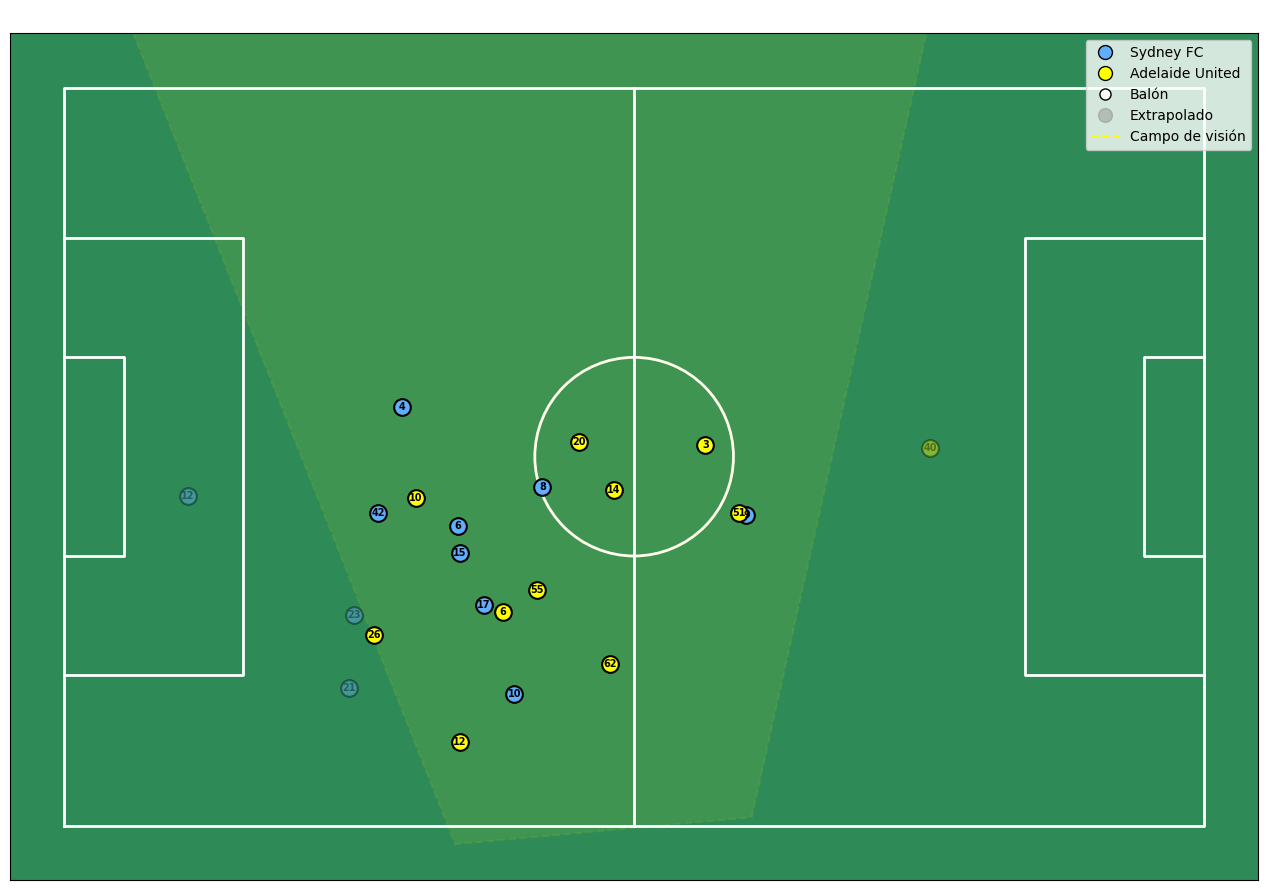

In [7]:
plot_frame(1996435, 150)

In [8]:
import numpy as np

def segment_intersects_circle(ax_p, ay_p, bx, by, cx, cy, radius):
    """Comprueba si el segmento AB intersecta el círculo centrado en C con el radio dado."""
    dx, dy = bx - ax_p, by - ay_p
    fx, fy = ax_p - cx, ay_p - cy
    a = dx * dx + dy * dy
    if a == 0:
        return (fx * fx + fy * fy) < radius * radius
    b = 2 * (fx * dx + fy * dy)
    c = fx * fx + fy * fy - radius * radius
    discriminant = b * b - 4 * a * c
    if discriminant < 0:
        return False
    discriminant = np.sqrt(discriminant)
    t1 = (-b - discriminant) / (2 * a)
    t2 = (-b + discriminant) / (2 * a)
    # El segmento intersecta si algún t está en [0, 1]
    return (0 <= t1 <= 1) or (0 <= t2 <= 1) or (t1 < 0 and t2 > 1)


def plot_passes(match_id, frame_num):
    match_dir = os.path.join(MATCHES_PATH, str(match_id))

    # Leer match.json para info de equipos y jugadores
    with open(os.path.join(match_dir, f"{match_id}{FILES_MATCH}")) as f:
        match_info = json.load(f)

    home_id = match_info['home_team']['id']
    home_name = match_info['home_team']['short_name']
    away_name = match_info['away_team']['short_name']
    home_color = match_info['home_team_kit']['jersey_color']
    away_color = match_info['away_team_kit']['jersey_color']
    pitch_length = match_info['pitch_length']
    pitch_width = match_info['pitch_width']

    player_team = {p['id']: p['team_id'] for p in match_info['players']}
    player_number = {p['id']: p['number'] for p in match_info['players']}

    # Filtrar df_players por match y frame
    frame_df = df_players[(df_players['match_id'] == match_id) & (df_players['frame'] == frame_num)]

    if frame_df.empty:
        print(f"No hay datos para match {match_id}, frame {frame_num}")
        return

    first_row = frame_df.iloc[0]

    # Identificar poseedor del balón
    poss_id = first_row['poss_player_id']
    if pd.notna(poss_id):
        poss_id = int(poss_id)
    else:
        # Fallback: jugador más cercano al balón
        if first_row['ball_is_detected'] != True:
            print(f"Frame {frame_num}: no hay balón detectado ni posesión registrada")
            return
        ball_x, ball_y = first_row['ball_x'], first_row['ball_y']
        dists = np.sqrt((frame_df['player_x'] - ball_x)**2 + (frame_df['player_y'] - ball_y)**2)
        poss_id = int(frame_df.loc[dists.idxmin(), 'player_player_id'])

    poss_team_id = player_team.get(poss_id)
    poss_row = frame_df[frame_df['player_player_id'] == poss_id].iloc[0]
    poss_x, poss_y = poss_row['player_x'], poss_row['player_y']

    # Separar compañeros y rivales
    teammates = frame_df[(frame_df['player_player_id'].map(player_team) == poss_team_id) &
                         (frame_df['player_player_id'] != poss_id)]
    rivals = frame_df[frame_df['player_player_id'].map(player_team) != poss_team_id]

    rival_positions = list(zip(rivals['player_x'], rivals['player_y']))
    BLOCK_RADIUS = 1.5

    # Dibujar campo
    fig, ax = plt.subplots(figsize=(14, 9))
    ax.set_xlim(-pitch_length / 2 - 5, pitch_length / 2 + 5)
    ax.set_ylim(-pitch_width / 2 - 5, pitch_width / 2 + 5)
    ax.set_aspect('equal')
    ax.set_facecolor('#2e8b57')

    half_l, half_w = pitch_length / 2, pitch_width / 2
    ax.plot([-half_l, half_l, half_l, -half_l, -half_l],
            [-half_w, -half_w, half_w, half_w, -half_w], 'w-', linewidth=2)
    ax.plot([0, 0], [-half_w, half_w], 'w-', linewidth=2)
    circle = plt.Circle((0, 0), 9.15, fill=False, color='white', linewidth=2)
    ax.add_patch(circle)
    for sign in [-1, 1]:
        ax.plot([sign * half_l, sign * (half_l - 16.5), sign * (half_l - 16.5), sign * half_l],
                [-20.16, -20.16, 20.16, 20.16], 'w-', linewidth=2)
        ax.plot([sign * half_l, sign * (half_l - 5.5), sign * (half_l - 5.5), sign * half_l],
                [-9.16, -9.16, 9.16, 9.16], 'w-', linewidth=2)

    # Dibujar círculos de bloqueo de rivales
    for rx, ry in rival_positions:
        block_circle = plt.Circle((rx, ry), BLOCK_RADIUS, fill=True,
                                  facecolor='red', alpha=0.15, edgecolor='red',
                                  linewidth=0.8, linestyle='--', zorder=2)
        ax.add_patch(block_circle)

    # Evaluar y dibujar líneas de pase
    n_valid, n_blocked = 0, 0
    for _, tm in teammates.iterrows():
        tx, ty = tm['player_x'], tm['player_y']
        blocked = any(
            segment_intersects_circle(poss_x, poss_y, tx, ty, rx, ry, BLOCK_RADIUS)
            for rx, ry in rival_positions
        )
        if blocked:
            ax.plot([poss_x, tx], [poss_y, ty], '-', color='red', linewidth=1, alpha=0.4, zorder=3)
            n_blocked += 1
        else:
            ax.plot([poss_x, tx], [poss_y, ty], '-', color='lime', linewidth=2, alpha=0.8, zorder=4)
            n_valid += 1

    # Dibujar jugadores
    for _, row in frame_df.iterrows():
        pid = row['player_player_id']
        tid = player_team.get(pid)
        color = home_color if tid == home_id else away_color
        number = player_number.get(pid, '')
        detected = row['player_is_detected'] == True
        alpha = 1.0 if detected else 0.4

        is_poss = (pid == poss_id)
        edge_w = 3 if is_poss else 1.5
        edge_c = 'yellow' if is_poss else 'black'
        size = 14 if is_poss else 12

        ax.plot(row['player_x'], row['player_y'], 'o', color=color, markersize=size,
                markeredgecolor=edge_c, markeredgewidth=edge_w, alpha=alpha, zorder=5)
        ax.text(row['player_x'], row['player_y'], str(number), ha='center', va='center',
                fontsize=7, fontweight='bold', color='black', alpha=alpha, zorder=6)

    # Dibujar balón
    if first_row['ball_is_detected'] == True:
        ax.plot(first_row['ball_x'], first_row['ball_y'], 'o', color='white', markersize=8,
                markeredgecolor='black', markeredgewidth=2, zorder=10)

    # Leyenda y título
    ax.plot([], [], 'o', color=home_color, markersize=10, markeredgecolor='black', label=home_name)
    ax.plot([], [], 'o', color=away_color, markersize=10, markeredgecolor='black', label=away_name)
    ax.plot([], [], 'o', color='gray', markersize=12, markeredgecolor='yellow', markeredgewidth=3, label='Poseedor')
    ax.plot([], [], '-', color='lime', linewidth=2, label=f'Pase libre ({n_valid})')
    ax.plot([], [], '-', color='red', linewidth=1, alpha=0.4, label=f'Pase bloqueado ({n_blocked})')
    ax.legend(loc='upper right', fontsize=10)

    poss_name = player_number.get(poss_id, '?')
    timestamp = first_row.get('timestamp', '?')
    period = first_row.get('period', '?')
    ax.set_title(f"Match {match_id} | Frame {frame_num} | Periodo {period} | {timestamp} | Poseedor: #{poss_name}",
                 fontsize=13, fontweight='bold', color='white')
    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout()
    plt.show()

Frame con posesión: 8913


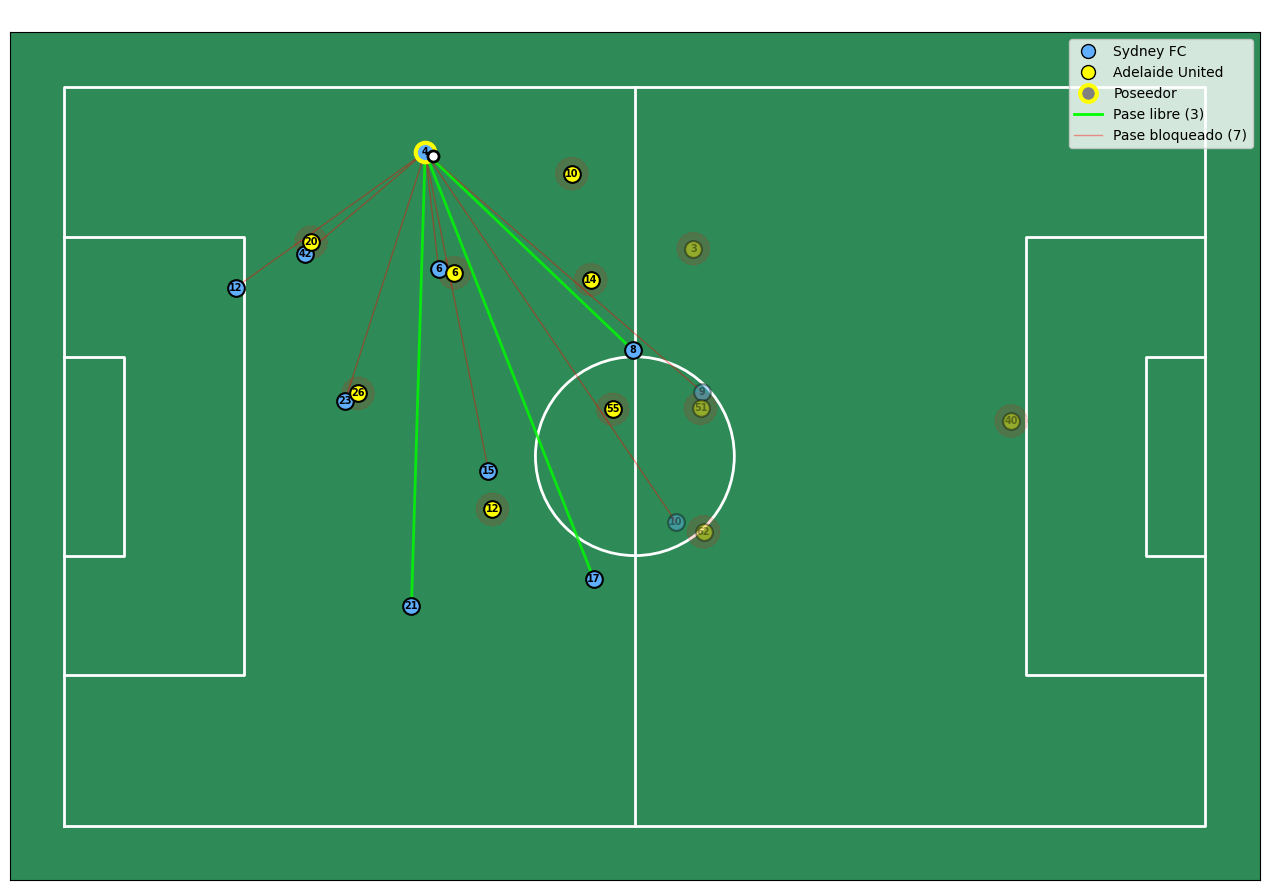

In [9]:
# Buscar un frame con posesión registrada para el ejemplo
sample = df_players[df_players['match_id'] == 1996435].drop_duplicates('frame')
with_poss = sample[sample['poss_player_id'].notna()].iloc[2000]
print(f"Frame con posesión: {int(with_poss['frame'])}")
plot_passes(1996435, int(with_poss['frame']))

In [10]:
def plot_movement(match_id, frame_num, n_frames):
    match_dir = os.path.join(MATCHES_PATH, str(match_id))

    with open(os.path.join(match_dir, f"{match_id}{FILES_MATCH}")) as f:
        match_info = json.load(f)

    home_id = match_info['home_team']['id']
    home_name = match_info['home_team']['short_name']
    away_name = match_info['away_team']['short_name']
    home_color = match_info['home_team_kit']['jersey_color']
    away_color = match_info['away_team_kit']['jersey_color']
    pitch_length = match_info['pitch_length']
    pitch_width = match_info['pitch_width']

    player_team = {p['id']: p['team_id'] for p in match_info['players']}
    player_number = {p['id']: p['number'] for p in match_info['players']}

    match_df = df_players[df_players['match_id'] == match_id]
    frame_start = match_df[match_df['frame'] == frame_num]
    frame_end = match_df[match_df['frame'] == frame_num + n_frames]

    if frame_start.empty or frame_end.empty:
        print(f"No hay datos para frame {frame_num} o {frame_num + n_frames}")
        return

    # Merge por player_id para emparejar posiciones inicio/fin
    merged = frame_start[['player_player_id', 'player_x', 'player_y', 'player_is_detected']].merge(
        frame_end[['player_player_id', 'player_x', 'player_y', 'player_is_detected']],
        on='player_player_id', suffixes=('_start', '_end')
    )

    # Datos del balón en ambos frames
    ball_start = frame_start.iloc[0]
    ball_end = frame_end.iloc[0]

    # Dibujar campo
    fig, ax = plt.subplots(figsize=(14, 9))
    ax.set_xlim(-pitch_length / 2 - 5, pitch_length / 2 + 5)
    ax.set_ylim(-pitch_width / 2 - 5, pitch_width / 2 + 5)
    ax.set_aspect('equal')
    ax.set_facecolor('#2e8b57')

    half_l, half_w = pitch_length / 2, pitch_width / 2
    ax.plot([-half_l, half_l, half_l, -half_l, -half_l],
            [-half_w, -half_w, half_w, half_w, -half_w], 'w-', linewidth=2)
    ax.plot([0, 0], [-half_w, half_w], 'w-', linewidth=2)
    circle = plt.Circle((0, 0), 9.15, fill=False, color='white', linewidth=2)
    ax.add_patch(circle)
    for sign in [-1, 1]:
        ax.plot([sign * half_l, sign * (half_l - 16.5), sign * (half_l - 16.5), sign * half_l],
                [-20.16, -20.16, 20.16, 20.16], 'w-', linewidth=2)
        ax.plot([sign * half_l, sign * (half_l - 5.5), sign * (half_l - 5.5), sign * half_l],
                [-9.16, -9.16, 9.16, 9.16], 'w-', linewidth=2)

    # Dibujar jugadores con flechas de movimiento
    for _, row in merged.iterrows():
        pid = row['player_player_id']
        tid = player_team.get(pid)
        color = home_color if tid == home_id else away_color
        number = player_number.get(pid, '')

        x0, y0 = row['player_x_start'], row['player_y_start']
        dx = row['player_x_end'] - x0
        dy = row['player_y_end'] - y0

        # Jugador en posición inicial
        ax.plot(x0, y0, 'o', color=color, markersize=12,
                markeredgecolor='black', markeredgewidth=1.5, zorder=5)
        ax.text(x0, y0, str(number), ha='center', va='center',
                fontsize=7, fontweight='bold', color='black', zorder=6)

        # Flecha de movimiento
        if abs(dx) > 0.01 or abs(dy) > 0.01:
            ax.annotate('', xy=(x0 + dx, y0 + dy), xytext=(x0, y0),
                        arrowprops=dict(arrowstyle='->', color=color,
                                        lw=2, shrinkA=6, shrinkB=0,
                                        mutation_scale=15),
                        zorder=4)

    # Dibujar balón con flecha de movimiento
    if ball_start['ball_is_detected'] == True:
        bx0, by0 = ball_start['ball_x'], ball_start['ball_y']
        ax.plot(bx0, by0, 'o', color='white', markersize=8,
                markeredgecolor='black', markeredgewidth=2, zorder=10)
        if ball_end['ball_is_detected'] == True:
            bdx = ball_end['ball_x'] - bx0
            bdy = ball_end['ball_y'] - by0
            if abs(bdx) > 0.01 or abs(bdy) > 0.01:
                ax.annotate('', xy=(bx0 + bdx, by0 + bdy), xytext=(bx0, by0),
                            arrowprops=dict(arrowstyle='->', color='white',
                                            lw=2.5, shrinkA=4, shrinkB=0,
                                            mutation_scale=15),
                            zorder=9)

    # Leyenda y título
    ax.plot([], [], 'o', color=home_color, markersize=10, markeredgecolor='black', label=home_name)
    ax.plot([], [], 'o', color=away_color, markersize=10, markeredgecolor='black', label=away_name)
    ax.plot([], [], 'o', color='white', markersize=8, markeredgecolor='black', label='Balón')
    ax.plot([], [], '-', color='white', linewidth=2, label=f'Movimiento ({n_frames} frames)')
    ax.legend(loc='upper right', fontsize=10)

    timestamp = ball_start.get('timestamp', '?')
    period = ball_start.get('period', '?')
    ax.set_title(f"Match {match_id} | Frames {frame_num}\u2192{frame_num + n_frames} | Periodo {period} | {timestamp}",
                 fontsize=13, fontweight='bold', color='white')
    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout()
    plt.show()

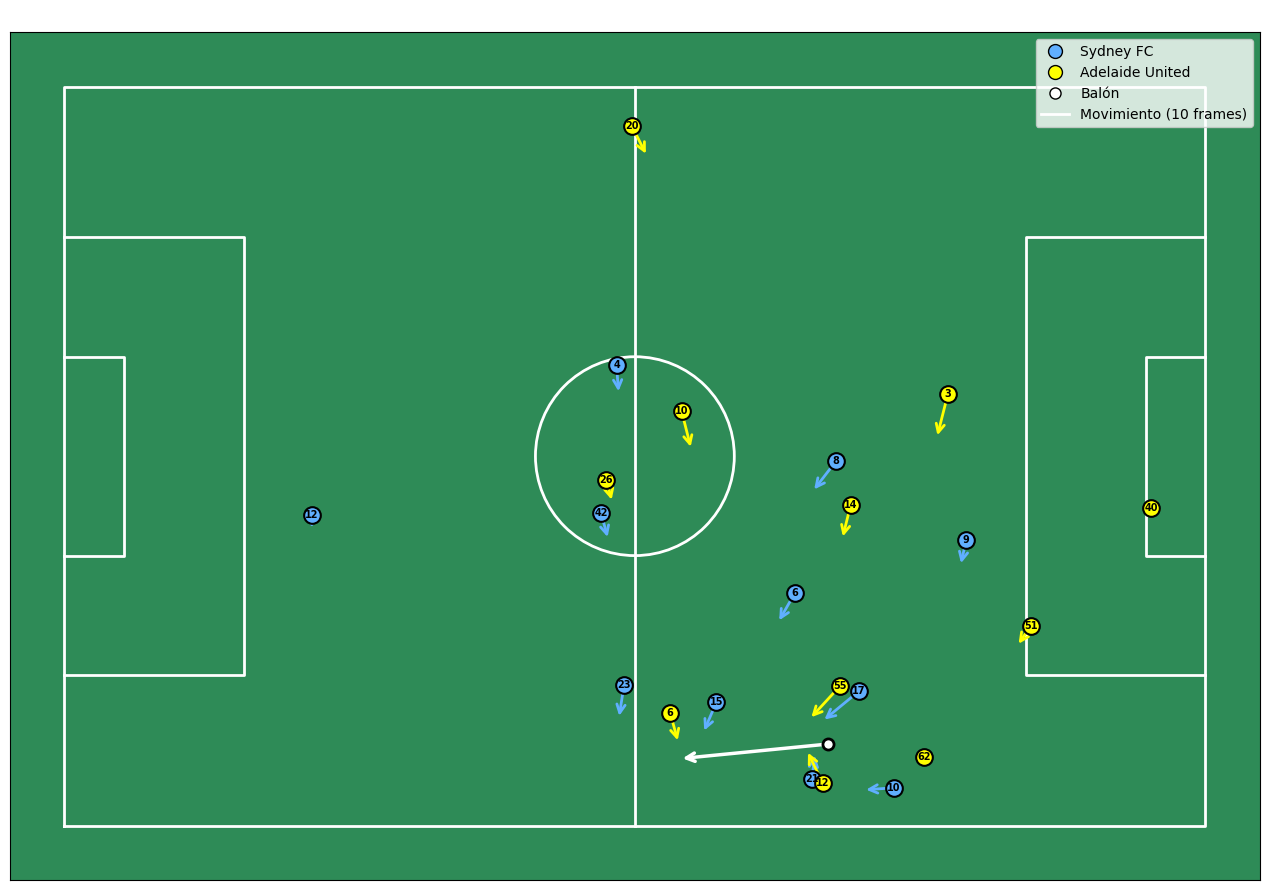

In [11]:
plot_movement(1996435, 470, 10)

In [12]:
# ============================================================
# STGCN - Paso 1: Preparación de datos
# ============================================================
N_HIS      = 50   # 5 segundos de historia  @ 10fps
N_PRED     = 30   # 3 segundos a predecir   @ 10fps
N_FRAME    = N_HIS + N_PRED  # 80 frames por secuencia
STRIDE     = 5    # paso de la ventana deslizante (0.5 segundos)
N_PLAYERS  = 22   # jugadores en el campo a la vez (11 por equipo)
N_NODES    = N_PLAYERS + 1  # + balón = 23
N_FEAT     = 2    # (x, y)
MAX_NAN_RATIO = 0.20

OUTPUT_DIR = 'stgcn_data'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"N_NODES = {N_NODES}  (22 jugadores + balón)")


def get_period_top_players(match_id, period, n=N_PLAYERS):
    """
    Devuelve los `n` player_ids que más frames aparecen en este periodo,
    ordenados por id para mantener orden consistente.
    Son los titulares + sustitutos que más tiempo jugaron.
    """
    pdf = df_players[
        (df_players['match_id'] == match_id) &
        (df_players['period'] == period)
    ]
    if pdf.empty:
        return []
    counts = pdf.groupby('player_player_id')['frame'].count().sort_values(ascending=False)
    top = sorted(counts.head(n).index.tolist())
    return top


def build_period_array(match_id, period):
    """
    Construye array [T, N_NODES, 2] para un partido y periodo.
    - Nodos 0..21: los 22 jugadores con más frames en este periodo (orden fijo por id)
    - Nodo 22: balón
    - 0 donde el jugador no tiene detección en ese frame
    - NaN solo para el balón cuando no es detectado
    """
    player_ids = get_period_top_players(match_id, period)
    if not player_ids:
        return None, None, None

    mdf = df[(df['match_id'] == match_id) & (df['period'] == period)].sort_values('frame')
    if mdf.empty:
        return None, None, None

    frames = mdf['frame'].values
    T = len(frames)
    arr = np.zeros((T, N_NODES, N_FEAT), dtype=np.float32)

    # --- Balón (nodo 22) ---
    arr[:, N_PLAYERS, 0] = mdf['ball_x'].values.astype(float)
    arr[:, N_PLAYERS, 1] = mdf['ball_y'].values.astype(float)
    no_ball = mdf['ball_x'].isna().values
    arr[no_ball, N_PLAYERS, :] = np.nan

    # --- Jugadores ---
    pdf = df_players[
        (df_players['match_id'] == match_id) &
        (df_players['period'] == period) &
        (df_players['player_player_id'].isin(player_ids))
    ][['frame', 'player_player_id', 'player_x', 'player_y']].copy()

    pid_to_idx   = {pid: i for i, pid in enumerate(player_ids)}
    frame_to_row = {f: i for i, f in enumerate(frames)}
    pdf = pdf[pdf['frame'].isin(frame_to_row)]

    row_idxs  = pdf['frame'].map(frame_to_row).values
    node_idxs = pdf['player_player_id'].map(pid_to_idx).values
    arr[row_idxs, node_idxs, 0] = pdf['player_x'].values.astype(float)
    arr[row_idxs, node_idxs, 1] = pdf['player_y'].values.astype(float)

    return arr, frames, player_ids


def interpolate_and_validate(seq):
    """
    seq: [N_FRAME, N_NODES, 2]
    Interpola NaN linealmente. Nodos todo-cero (jugador ausente en la ventana) se ignoran.
    Retorna (seq_interp, valid).

    Condiciones de rechazo:
      - Algún frame donde el balón no tiene datos en absoluto
      - NaN ratio en nodos activos > MAX_NAN_RATIO
      - Algún nodo activo completamente sin datos en toda la ventana
    """
    ball_idx = N_PLAYERS  # nodo 22

    # Rechazo inmediato si en cualquier frame el balón no tiene datos
    ball_nan_per_frame = np.isnan(seq[:, ball_idx, :]).all(axis=1)  # [N_FRAME] bool
    if ball_nan_per_frame.any():
        return seq, False

    # Nodos activos: tienen algún valor != 0
    active_nodes = [i for i in range(N_NODES) if not np.all(seq[:, i, :] == 0)]

    nan_ratio = np.isnan(seq[:, active_nodes, :]).sum() / max(seq[:, active_nodes, :].size, 1)
    if nan_ratio > MAX_NAN_RATIO:
        return seq, False

    seq_out = seq.copy()
    for node in active_nodes:
        for feat in range(N_FEAT):
            ts = seq_out[:, node, feat].copy()
            nans = np.isnan(ts)
            if not nans.any():
                continue
            if nans.all():
                return seq_out, False
            idx = np.arange(len(ts))
            ts[nans] = np.interp(idx[nans], idx[~nans], ts[~nans])
            seq_out[:, node, feat] = ts

    return seq_out, True


def build_sequences(match_ids=None):
    """
    Genera secuencias [N_FRAME, N_NODES, 2] para todos los partidos.
    Retorna:
        sequences  : np.ndarray [N_seq, N_FRAME, N_NODES, 2]
        node_orders: dict {match_id: {period: [player_ids]}}
    """
    if match_ids is None:
        match_ids = sorted(df['match_id'].unique().tolist())

    all_seqs   = []
    node_orders = {}

    for match_id in match_ids:
        node_orders[match_id] = {}

        for period in [1, 2]:
            arr, frames, player_ids = build_period_array(match_id, period)
            if arr is None:
                continue

            node_orders[match_id][period] = player_ids
            T = len(arr)
            n_windows = 0

            for start in range(0, T - N_FRAME + 1, STRIDE):
                seq = arr[start:start + N_FRAME]
                seq_interp, valid = interpolate_and_validate(seq)
                if valid:
                    all_seqs.append(seq_interp)
                    n_windows += 1

            print(f"  Match {match_id} | Periodo {period} | Frames: {T} | Secuencias válidas: {n_windows}")

    if not all_seqs:
        raise ValueError("No se generó ninguna secuencia válida.")

    sequences = np.stack(all_seqs, axis=0)
    print(f"\nTotal secuencias: {sequences.shape[0]}")
    print(f"Shape: {sequences.shape}  →  (N_seq, N_FRAME={N_FRAME}, N_NODES={N_NODES}, N_FEAT={N_FEAT})")
    return sequences, node_orders


N_NODES = 23  (22 jugadores + balón)


In [ ]:

sequences, node_orders = build_sequences()

match_ids_sorted = sorted(df['match_id'].unique().tolist())

seqs_per_match = {}
for match_id in match_ids_sorted:
    count = 0
    for period in [1, 2]:
        arr, frames, _ = build_period_array(match_id, period)
        if arr is not None:
            T = len(arr)
            for start in range(0, T - N_FRAME + 1, STRIDE):
                _, valid = interpolate_and_validate(arr[start:start + N_FRAME])
                if valid:
                    count += 1
    seqs_per_match[match_id] = count


# Split: 8 train / 1 val / 1 test
train_matches = match_ids_sorted[:8]
val_matches   = match_ids_sorted[8:9]

train_cut = sum(seqs_per_match[m] for m in train_matches)
val_cut   = train_cut + sum(seqs_per_match[m] for m in val_matches)

seq_train = sequences[:train_cut]
seq_val   = sequences[train_cut:val_cut]
seq_test  = sequences[val_cut:]

print(f"\nTrain: {seq_train.shape}")
print(f"Val:   {seq_val.shape}")
print(f"Test:  {seq_test.shape}")

# Z-score calculado solo sobre train
mean_xy = seq_train.mean(axis=(0, 1, 2))  # [2]
std_xy  = seq_train.std(axis=(0, 1, 2))   # [2]
print(f"\nMedia (x,y): {mean_xy}")
print(f"Std   (x,y): {std_xy}")

seq_train_norm = (seq_train - mean_xy) / std_xy
seq_val_norm   = (seq_val   - mean_xy) / std_xy
seq_test_norm  = (seq_test  - mean_xy) / std_xy

np.save(os.path.join(OUTPUT_DIR, 'seq_train.npy'), seq_train_norm)
np.save(os.path.join(OUTPUT_DIR, 'seq_val.npy'),   seq_val_norm)
np.save(os.path.join(OUTPUT_DIR, 'seq_test.npy'),  seq_test_norm)
np.save(os.path.join(OUTPUT_DIR, 'mean_std.npy'),  np.stack([mean_xy, std_xy]))

import pickle
with open(os.path.join(OUTPUT_DIR, 'node_orders.pkl'), 'wb') as f:
    pickle.dump(node_orders, f)

print(f"\nDatos guardados en '{OUTPUT_DIR}/'")
print(f"  Shape final: {sequences.shape}  →  (N_seq, {N_FRAME}, {N_NODES}, {N_FEAT})")

  Match 1886347 | Periodo 1 | Frames: 27781 | Secuencias válidas: 4238
  Match 1886347 | Periodo 2 | Frames: 31261 | Secuencias válidas: 3429
  Match 1899585 | Periodo 1 | Frames: 29751 | Secuencias válidas: 3585
  Match 1899585 | Periodo 2 | Frames: 30760 | Secuencias válidas: 3403
  Match 1925299 | Periodo 1 | Frames: 30231 | Secuencias válidas: 4411
  Match 1925299 | Periodo 2 | Frames: 31051 | Secuencias válidas: 4350
  Match 1953632 | Periodo 1 | Frames: 28961 | Secuencias válidas: 4261
  Match 1953632 | Periodo 2 | Frames: 30270 | Secuencias válidas: 3410
  Match 1996435 | Periodo 1 | Frames: 28011 | Secuencias válidas: 3974
  Match 1996435 | Periodo 2 | Frames: 29591 | Secuencias válidas: 3620
  Match 2006229 | Periodo 1 | Frames: 28471 | Secuencias válidas: 3880
  Match 2006229 | Periodo 2 | Frames: 30780 | Secuencias válidas: 3973
  Match 2011166 | Periodo 1 | Frames: 28991 | Secuencias válidas: 3200
  Match 2011166 | Periodo 2 | Frames: 30301 | Secuencias válidas: 3471
  Matc

Frames para adyacencia: 4,886,160
Distancia media mín: 18.7 m
Distancia media máx: 38.0 m
Distancia media global: 25.7 m

σ  = 25.7 m  (distancia media típica)
σ² = 662.4 m²
Conexiones activas: 506  (grafo completo, todos los pares)
Rango de pesos W: [0.1132, 0.5901]

W_adjacency.npy guardado


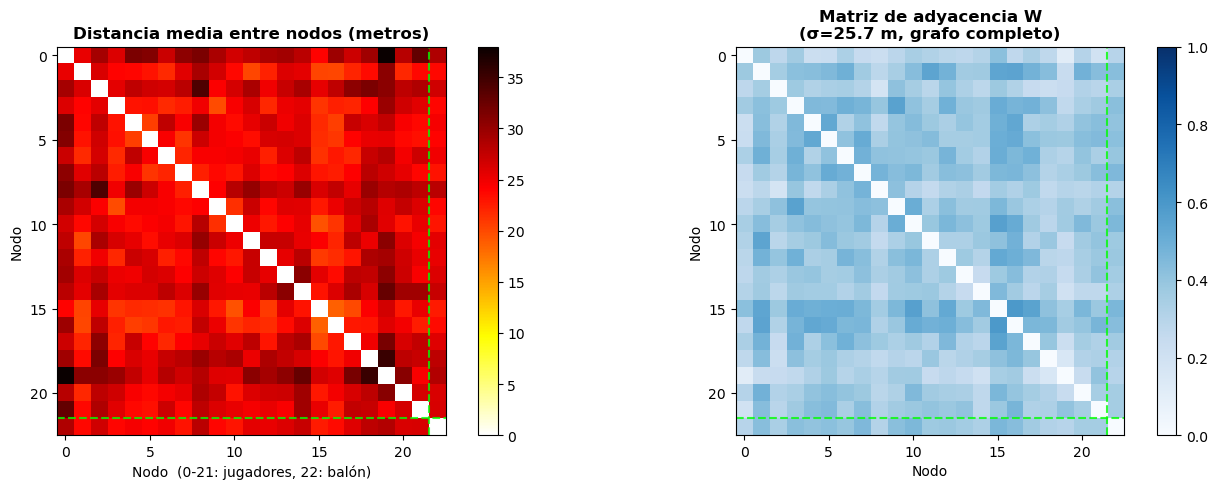

In [ ]:
# ============================================================
# STGCN - Paso 2: Matriz de adyacencia estática
# ============================================================
seq_train_raw = np.load(os.path.join(OUTPUT_DIR, 'seq_train.npy'))
mean_std      = np.load(os.path.join(OUTPUT_DIR, 'mean_std.npy'))
mean_xy, std_xy = mean_std[0], mean_std[1]

# Desnormalizar → metros reales
seq_train_meters = seq_train_raw * std_xy + mean_xy   # [N, 80, 23, 2]
train_positions  = seq_train_meters.reshape(-1, N_NODES, N_FEAT) #[N*80, 23, 2]

print(f"Frames para adyacencia: {train_positions.shape[0]:,}")

# --- Distancia media euclidiana entre cada par de nodos (en metros) ---
chunk_size = 10_000
n_frames   = train_positions.shape[0]
sum_dist   = np.zeros((N_NODES, N_NODES), dtype=np.float64)

for start in range(0, n_frames, chunk_size):
    chunk    = train_positions[start:start + chunk_size]
    diff     = chunk[:, :, np.newaxis, :] - chunk[:, np.newaxis, :, :]
    sum_dist += np.sqrt((diff ** 2).sum(axis=-1)).sum(axis=0)

mean_dist = (sum_dist / n_frames).astype(np.float32)

off_diag = mean_dist[mean_dist > 0]
print(f"Distancia media mín: {off_diag.min():.1f} m")
print(f"Distancia media máx: {off_diag.max():.1f} m")
print(f"Distancia media global: {off_diag.mean():.1f} m")

# --- Gaussian kernel con σ calibrado para fútbol ---
# En carreteras, var(distancias) calibra bien porque hay mucha variabilidad.
# En fútbol las distancias son grandes y similares → var es pequeña → kernel colapsa.
# Usamos σ = media de distancias off-diagonal (grafo completamente conectado, ε=0).
# Esto hace que la mitad de los pares tengan peso > exp(-1) ≈ 0.37.
sigma2 = off_diag.mean() ** 2   # σ = distancia media típica entre jugadores

W = np.exp(-mean_dist ** 2 / sigma2)
np.fill_diagonal(W, 0)          # sin auto-conexiones
# ε = 0: grafo completamente conectado — en fútbol cualquier jugador puede
# influir en cualquier otro, sin restricción topológica como en carreteras.
W = (W + W.T) / 2               # simetría

n_edges = int((W > 0).sum())
print(f"\nσ  = {np.sqrt(sigma2):.1f} m  (distancia media típica)")
print(f"σ² = {sigma2:.1f} m²")
print(f"Conexiones activas: {n_edges}  (grafo completo, todos los pares)")
print(f"Rango de pesos W: [{W[W>0].min():.4f}, {W[W>0].max():.4f}]")

np.save(os.path.join(OUTPUT_DIR, 'W_adjacency.npy'), W.astype(np.float32))
print(f"\nW_adjacency.npy guardado")

# --- Visualización ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(mean_dist, cmap='hot_r')
axes[0].set_title('Distancia media entre nodos (metros)', fontweight='bold')
axes[0].set_xlabel('Nodo  (0-21: jugadores, 22: balón)')
axes[0].set_ylabel('Nodo')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(W, cmap='Blues', vmin=0, vmax=1)
axes[1].set_title(f'Matriz de adyacencia W\n(σ={np.sqrt(sigma2):.1f} m, grafo completo)', fontweight='bold')
axes[1].set_xlabel('Nodo')
axes[1].set_ylabel('Nodo')
plt.colorbar(im1, ax=axes[1])

for ax in axes:
    ax.axhline(N_PLAYERS - 0.5, color='lime', linewidth=1.5, linestyle='--', alpha=0.8)
    ax.axvline(N_PLAYERS - 0.5, color='lime', linewidth=1.5, linestyle='--', alpha=0.8)

plt.tight_layout()
plt.show()

Calculando Laplaciano escalado para N=23 nodos, Ks=3...
λ_max = 1.0776
L̃ rango: [-0.1167, 0.8560]  (esperado: [-1, 1])
Lk shape: (23, 69)  →  [n=23, Ks*n=3*23=69]

Guardado: Lk_chebyshev.npy  (23, 69)
Guardado: L_tilde.npy       (23, 23)


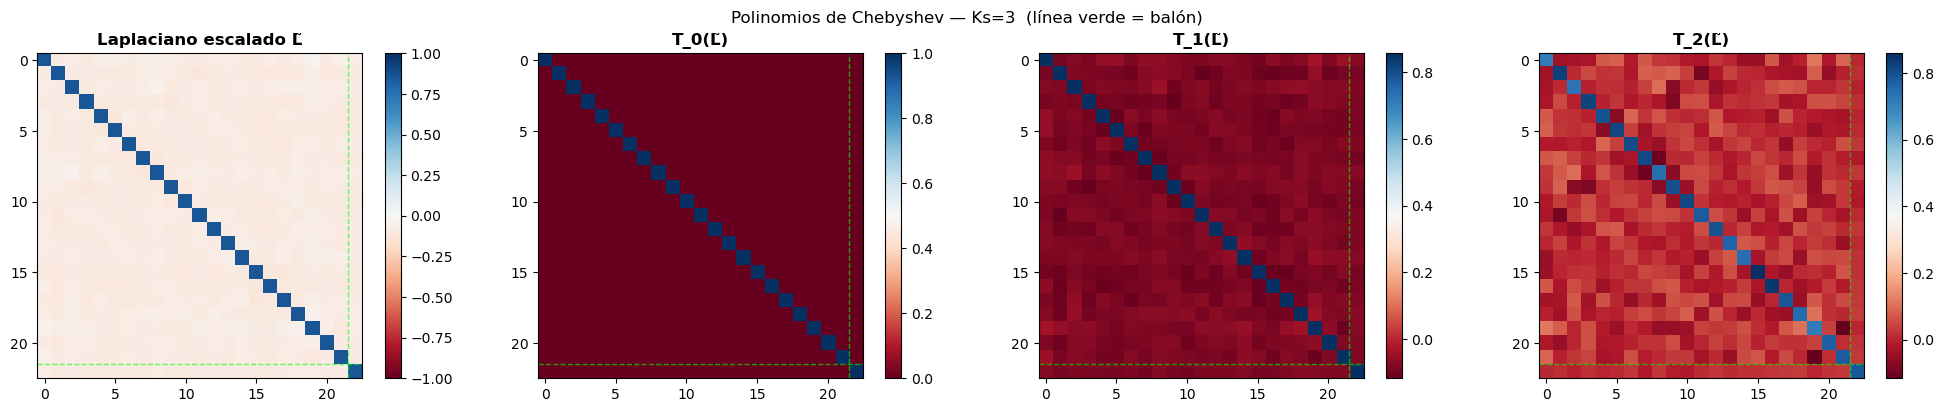


Resumen de lo que entra al modelo:
  W  [23×23]       → pesos de adyacencia
  Lk [23×69]      → base fija de la graph conv (no entrenable)
  Ks = 3            → radio del filtro espacial (2 saltos de vecindario)


In [15]:
# ============================================================
# STGCN - Paso 3: Laplaciano escalado y polinomios de Chebyshev
# ============================================================
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh

KS = 3  # orden del polinomio de Chebyshev (vecindario de radio KS-1 saltos)
        # KS=3 → cada nodo ve sus vecinos directos y los vecinos de sus vecinos

W = np.load(os.path.join(OUTPUT_DIR, 'W_adjacency.npy'))
n = W.shape[0]  # = N_NODES = 23


def scaled_laplacian(W):
    """
    Laplaciano normalizado escalado al rango [-1, 1]:
      L  = I - D^{-1/2} W D^{-1/2}
      L̃  = 2L / λ_max - I
    """
    D = np.diag(W.sum(axis=1))
    d_inv_sqrt = np.diag(1.0 / np.sqrt(W.sum(axis=1) + 1e-8))
    L = np.eye(n) - d_inv_sqrt @ W @ d_inv_sqrt

    # λ_max: mayor autovalor de L (usamos sparse eigsh para eficiencia)
    L_sparse = csr_matrix(L)
    lambda_max = eigsh(L_sparse, k=1, which='LM', return_eigenvectors=False)[0]
    lambda_max = float(lambda_max)

    L_tilde = (2.0 / lambda_max) * L - np.eye(n)
    return L_tilde.astype(np.float32), lambda_max


def cheb_poly(L_tilde, Ks):
    """
    Genera los Ks polinomios de Chebyshev evaluados en L̃:
      T_0(L̃) = I
      T_1(L̃) = L̃
      T_k(L̃) = 2·L̃·T_{k-1} - T_{k-2}

    Retorna array [n, Ks*n] — los Ks matrices apiladas horizontalmente.
    Este array se pasa al graph conv como base fija (no entrenable).
    """
    polys = [np.eye(n, dtype=np.float32)]     # T_0
    if Ks == 1:
        return np.concatenate(polys, axis=1)

    polys.append(L_tilde.copy())               # T_1
    for k in range(2, Ks):
        Tk = 2 * L_tilde @ polys[-1] - polys[-2]
        polys.append(Tk.astype(np.float32))

    return np.concatenate(polys, axis=1)       # [n, Ks*n]


# --- Calcular ---
print(f"Calculando Laplaciano escalado para N={n} nodos, Ks={KS}...")
L_tilde, lambda_max = scaled_laplacian(W)
Lk = cheb_poly(L_tilde, KS)

print(f"λ_max = {lambda_max:.4f}")
print(f"L̃ rango: [{L_tilde.min():.4f}, {L_tilde.max():.4f}]  (esperado: [-1, 1])")
print(f"Lk shape: {Lk.shape}  →  [n={n}, Ks*n={KS}*{n}={KS*n}]")

# Guardar
np.save(os.path.join(OUTPUT_DIR, 'Lk_chebyshev.npy'), Lk)
np.save(os.path.join(OUTPUT_DIR, 'L_tilde.npy'), L_tilde)
print(f"\nGuardado: Lk_chebyshev.npy  {Lk.shape}")
print(f"Guardado: L_tilde.npy       {L_tilde.shape}")

# --- Visualización ---
fig, axes = plt.subplots(1, KS + 1, figsize=(5 * (KS + 1), 4))

im = axes[0].imshow(L_tilde, cmap='RdBu', vmin=-1, vmax=1)
axes[0].set_title('Laplaciano escalado L̃', fontweight='bold')
plt.colorbar(im, ax=axes[0])

for k in range(KS):
    Tk = Lk[:, k*n:(k+1)*n]
    im = axes[k+1].imshow(Tk, cmap='RdBu')
    axes[k+1].set_title(f'T_{k}(L̃)', fontweight='bold')
    plt.colorbar(im, ax=axes[k+1])

for ax in axes:
    ax.axhline(N_PLAYERS - 0.5, color='lime', linewidth=1, linestyle='--', alpha=0.6)
    ax.axvline(N_PLAYERS - 0.5, color='lime', linewidth=1, linestyle='--', alpha=0.6)

plt.suptitle(f'Polinomios de Chebyshev — Ks={KS}  (línea verde = balón)', fontsize=12)
plt.tight_layout()
plt.show()

print("\nResumen de lo que entra al modelo:")
print(f"  W  [23×23]       → pesos de adyacencia")
print(f"  Lk [23×{KS*n}]      → base fija de la graph conv (no entrenable)")
print(f"  Ks = {KS}            → radio del filtro espacial ({KS-1} saltos de vecindario)")

In [2]:
import pandas as pd

events = pd.read_csv('C:\\Users\\Eloy Mercader\\OneDrive - EDISA SISTEMAS DE INFORMACION, SA\\Escritorio\\eloi edisa\\projectes\\tracking\\opendata\\data\\matches\\1899585\\1899585_dynamic_events.csv')

C:\Users\Eloy Mercader\AppData\Local\Temp\ipykernel_20940\2678730753.py:3: DtypeWarning: Columns (276) have mixed types. Specify dtype option on import or set low_memory=False.
  events = pd.read_csv('C:\\Users\\Eloy Mercader\\OneDrive - EDISA SISTEMAS DE INFORMACION, SA\\Escritorio\\eloi edisa\\projectes\\tracking\\opendata\\data\\matches\\1899585\\1899585_dynamic_events.csv')


In [ ]:
events['event_type'].unique()

array(['player_possession', 'passing_option', 'on_ball_engagement',
       'off_ball_run'], dtype=object)

In [6]:
import os
matches_path = r'C:\Users\Eloy Mercader\OneDrive - EDISA SISTEMAS DE INFORMACION, SA\Escritorio\eloi edisa\projectes\tracking\opendata\data\matches'
for match in os.listdir(matches_path):
    events = pd.read_csv(os.path.join(matches_path, match, f'{match}_dynamic_events.csv'))
    print(events['event_type'].unique())


['player_possession' 'passing_option' 'on_ball_engagement' 'off_ball_run']
['player_possession' 'passing_option' 'on_ball_engagement' 'off_ball_run']


C:\Users\Eloy Mercader\AppData\Local\Temp\ipykernel_20940\2295300804.py:4: DtypeWarning: Columns (276) have mixed types. Specify dtype option on import or set low_memory=False.
  events = pd.read_csv(os.path.join(matches_path, match, f'{match}_dynamic_events.csv'))


['player_possession' 'off_ball_run' 'passing_option' 'on_ball_engagement']
['player_possession' 'off_ball_run' 'passing_option' 'on_ball_engagement']
['player_possession' 'off_ball_run' 'passing_option' 'on_ball_engagement']
['player_possession' 'passing_option' 'on_ball_engagement' 'off_ball_run']
['player_possession' 'passing_option' 'off_ball_run' 'on_ball_engagement']
['player_possession' 'passing_option' 'off_ball_run' 'on_ball_engagement']
['player_possession' 'on_ball_engagement' 'passing_option' 'off_ball_run']
['player_possession' 'off_ball_run' 'passing_option' 'on_ball_engagement']


C:\Users\Eloy Mercader\AppData\Local\Temp\ipykernel_20940\2295300804.py:4: DtypeWarning: Columns (75,77,184,264) have mixed types. Specify dtype option on import or set low_memory=False.
  events = pd.read_csv(os.path.join(matches_path, match, f'{match}_dynamic_events.csv'))


In [2]:
events.columns

Index(['event_id', 'index', 'match_id', 'frame_start', 'frame_end',
       'frame_physical_start', 'time_start', 'time_end', 'minute_start',
       'second_start',
       ...
       'xloss_player_possession_end', 'xloss_player_possession_max',
       'xshot_player_possession_start', 'xshot_player_possession_end',
       'xshot_player_possession_max', 'is_player_possession_start_matched',
       'is_player_possession_end_matched', 'is_previous_pass_matched',
       'is_pass_reception_matched', 'fully_extrapolated'],
      dtype='object', length=294)

In [8]:
events['phase_index']

0         0
1         0
2         0
3         0
4         0
       ... 
4708    459
4709    459
4710    459
4711    459
4712    459
Name: phase_index, Length: 4713, dtype: int64

In [1]:
from stgcn_tracking.generate_graph import FrameTracking, MatchGraphBuilder

In [16]:
builder = MatchGraphBuilder(
    tracking_path="opendata/data/matches/1886347/1886347_tracking_extrapolated.jsonl",
    dynamic_events_path="opendata/data/matches/1886347/1886347_dynamic_events.csv",
    phases_path="opendata/data/matches/1886347/1886347_phases_of_play.csv",
)

builder.load_data()

phase = builder.get_phase_interval(
    period=1,
    team_in_possession_phase_type="create",
)


tracking_frames = builder.get_tracking_frames_for_phase(phase)
dynamic_events_in_phase = builder.get_dynamic_events_for_phase(phase)

print(phase[["frame_start", "frame_end", "team_in_possession_phase_type", "team_out_of_possession_phase_type"]])
print(f"Número de frames de tracking en la fase: {len(tracking_frames)}")
print(f"Número de dynamic events que solapan con la fase: {len(dynamic_events_in_phase)}")

Error al procesar frame 0: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'
Error al procesar frame 1: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'
Error al procesar frame 2: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'
Error al procesar frame 3: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'
Error al procesar frame 4: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'
Error al procesar frame 5: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'
Error al procesar frame 6: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'
Error al procesar frame 7: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'
Error al procesar frame 8: int() argument must be a string, a bytes-like object or a real number

In [7]:
tracking_frames[0].player_data

[{'x': -40.71, 'y': -0.27, 'player_id': 51009, 'is_detected': False},
 {'x': -19.33, 'y': -9.63, 'player_id': 176224, 'is_detected': True},
 {'x': -21.72, 'y': 0.22, 'player_id': 51649, 'is_detected': True},
 {'x': -0.64, 'y': -33.03, 'player_id': 50983, 'is_detected': True},
 {'x': -20.11, 'y': 15.75, 'player_id': 735578, 'is_detected': True},
 {'x': -6.52, 'y': 6.95, 'player_id': 50978, 'is_detected': True},
 {'x': -9.58, 'y': -5.04, 'player_id': 735574, 'is_detected': True},
 {'x': -0.15, 'y': 8.15, 'player_id': 795507, 'is_detected': True},
 {'x': -1.09, 'y': -20.49, 'player_id': 795505, 'is_detected': True},
 {'x': -1.08, 'y': 18.69, 'player_id': 735573, 'is_detected': True},
 {'x': 0.73, 'y': 0.49, 'player_id': 966120, 'is_detected': True},
 {'x': 41.94, 'y': 0.14, 'player_id': 285188, 'is_detected': False},
 {'x': 17.93, 'y': 4.82, 'player_id': 51667, 'is_detected': True},
 {'x': 17.43, 'y': -3.57, 'player_id': 33697, 'is_detected': True},
 {'x': 16.53, 'y': 14.09, 'player_id': 

In [23]:

dynamic_events_in_phase.head()


,event_id,index,match_id,frame_start,frame_end,frame_physical_start,time_start,time_end,minute_start,second_start,...,xloss_player_possession_end,xloss_player_possession_max,xshot_player_possession_start,xshot_player_possession_end,xshot_player_possession_max,is_player_possession_start_matched,is_player_possession_end_matched,is_previous_pass_matched,is_pass_reception_matched,fully_extrapolated
0,8_0,0,1886347,28,28,NaN,00:01.8,00:01.8,0,1,...,NaN,NaN,NaN,NaN,NaN,True,True,NaN,True,False
1,8_1,1,1886347,48,58,NaN,00:03.8,00:04.8,0,3,...,NaN,NaN,NaN,NaN,NaN,True,True,True,True,False
2,7_0,2,1886347,48,53,NaN,00:03.8,00:04.3,0,3,...,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,False
3,7_1,3,1886347,48,58,NaN,00:03.8,00:04.8,0,3,...,NaN,NaN,NaN,NaN,NaN,True,True,NaN,True,False
4,9_0,4,1886347,56,58,34.0,00:02.4,00:04.8,0,2,...,NaN,NaN,NaN,NaN,NaN,True,True,True,True,NaN


In [20]:
types_events = dynamic_events_in_phase['event_type']
types_events 

0      player_possession
1      player_possession
2         passing_option
3         passing_option
4     on_ball_engagement
5      player_possession
6         passing_option
7         passing_option
8         passing_option
9         passing_option
10          off_ball_run
11    on_ball_engagement
12          off_ball_run
13          off_ball_run
Name: event_type, dtype: object

In [24]:
dynamic_events_in_phase['team_id']

0     1805
1     1805
2     1805
3     1805
4     4177
5     1805
6     1805
7     1805
8     1805
9     1805
10    1805
11    4177
12    1805
13    1805
Name: team_id, dtype: int64

In [5]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ----------- ---------------------------- 2.9/9.8 MB 21.3 MB/s eta 0:00:01
   -------------------------- ------------- 6.6/9.8 MB 18.5 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 20.7 MB/s  0:00:00

   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [panda


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\eloim\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


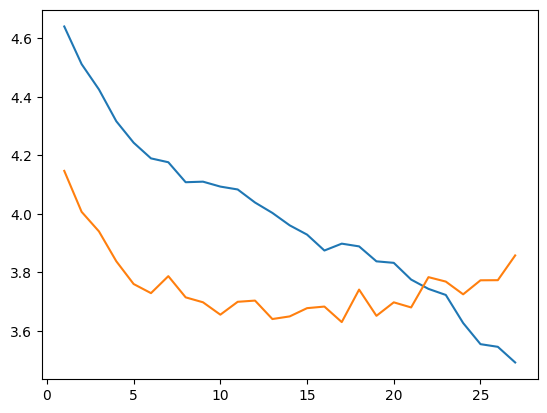

In [9]:
import matplotlib.pyplot as plt 
import pandas as pd
train_results = pd.read_csv('multi_head_output/train_log.csv')

x = train_results['epoch']
for c in ['train_total', 'val_total']:
    plt.plot(x, train_results[c])